# Quantumtunneling door een rechthoekige potentiaalbarrière

## Probleemstelling

We beschouwen een **rechthoekige potentiaalbarrière** in 1D:

$$V(x) = \begin{cases} 
0 & \text{voor } x < 0 \text{ (Regio I)} \\
V_0 & \text{voor } 0 \leq x \leq a \text{ (Regio II)} \\
0 & \text{voor } x > a \text{ (Regio III)}
\end{cases}$$

Een deeltje met energie $E$ wordt op deze barrière geschoten. We onderzoeken twee scenario's:

1. **Tunneling-regime**: $E < V_0$ — klassiek zou het deeltje volledig worden gereflecteerd, maar quantummechanisch kan het tunnelen
2. **Boven de barrière**: $E > V_0$ — het deeltje heeft genoeg energie om over de barrière te gaan

## Oplossingsmethode

We lossen de **tijdsonafhankelijke Schrödingervergelijking** op:

$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} + V(x)\psi = E\psi$$

### Golffuncties per regio

**Regio I** ($x < 0$, $V=0$):
- Invallende golf: $e^{ikx}$ (genormaliseerd op amplitude 1)
- Gereflecteerde golf: $r \cdot e^{-ikx}$
- Totaal: $\psi_I(x) = e^{ikx} + r \cdot e^{-ikx}$

**Regio II** ($0 \leq x \leq a$, $V=V_0$):
- Voor $E < V_0$: evanescente golf met $\psi_{II}(x) = A e^{\kappa x} + B e^{-\kappa x}$ waar $\kappa = \sqrt{2m(V_0-E)}/\hbar$
- Voor $E > V_0$: oscillerende golf met $\psi_{II}(x) = A e^{iqx} + B e^{-iqx}$ waar $q = \sqrt{2m(E-V_0)}/\hbar$

**Regio III** ($x > a$, $V=0$):
- Getransmitteerde golf: $t \cdot e^{ikx}$
- Totaal: $\psi_{III}(x) = t \cdot e^{ikx}$

Hierbij is $k = \sqrt{2mE}/\hbar$ de golfvector in de vrije regio's.

### Randvoorwaarden

De golffunctie en zijn afgeleide moeten **continu** zijn bij $x=0$ en $x=a$:

1. Bij $x=0$: $\psi_I(0) = \psi_{II}(0)$ en $\psi'_I(0) = \psi'_{II}(0)$
2. Bij $x=a$: $\psi_{II}(a) = \psi_{III}(a)$ en $\psi'_{II}(a) = \psi'_{III}(a)$

Dit geeft een stelsel van 4 vergelijkingen met 4 onbekenden: $r$, $t$, $A$, $B$.

## Reflectie- en transmissiecoëfficiënten

- **Reflectiecoëfficiënt**: $R = |r|^2$ (fractie gereflecteerd)
- **Transmissiecoëfficiënt**: $T = |t|^2$ (fractie getransmitteerd)
- Behoud van waarschijnlijkheid: $R + T = 1$

Voor het tunneling-regime ($E < V_0$) geldt bij benadering:

$$T \approx e^{-2\kappa a} = \exp\left(-\frac{2a}{\hbar}\sqrt{2m(V_0-E)}\right)$$

Dit laat zien dat de tunnelkans **exponentieel afneemt** met de breedte $a$ en de "hoogte" $V_0 - E$ van de barrière.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def barrier_potential(x, V0=1.0, a=1.0):
    """Rechthoekige barrière: V=V0 op (0,a), anders 0."""
    return np.where((x >= 0) & (x <= a), V0, 0.0)

def solve_rect_barrier(E, V0, a, m=1.0, hbar=1.0, incident_from="left"):
    """
    Los de 1D stationaire Schrödingervergelijking op voor een rechthoekige barrière.
    Incident_from: "left" of "right".
    Geeft dict met k, (kappa of q), en amplitudes r, t, A, B.
    """
    i = 1j
    k = np.sqrt(2*m*E) / hbar  # golfvector buiten barrière (V=0)

    if E < V0:
        kappa = np.sqrt(2*m*(V0 - E)) / hbar  # evanescent binnen
        ea, ema = np.exp(kappa*a), np.exp(-kappa*a)
        eika = np.exp(i*k*a)
        e_minusika = np.exp(-i*k*a)

        if incident_from == "left":
            # Regio I (x<0):  e^{ikx} + r e^{-ikx}
            # Regio II (0<x<a): A e^{kappa x} + B e^{-kappa x}
            # Regio III (x>a): t e^{ikx}
            M = np.array([
                [1,      -1,        -1,        0],
                [-i*k,   -kappa,     kappa,     0],
                [0,       ea,        ema,      -eika],
                [0,   kappa*ea, -kappa*ema, -i*k*eika]
            ], dtype=complex)
            b = np.array([-1, -i*k, 0, 0], dtype=complex)
            r, A, B, t = np.linalg.solve(M, b)

        elif incident_from == "right":
            # Regio III (x>a): e^{-ikx} + r e^{ikx} (invallend van rechts)
            # Regio II (0<x<a): A e^{kappa x} + B e^{-kappa x}
            # Regio I (x<0): t e^{-ikx} (transmissie naar links)
            # Onbekenden in volgorde [t, A, B, r]
            M = np.array([
                [0,       ea,        ema,      -eika],
                [0,   kappa*ea, -kappa*ema, -i*k*eika],
                [-1,       1,         1,        0],
                [ i*k,   kappa,    -kappa,      0]
            ], dtype=complex)
            b = np.array([e_minusika, -i*k*e_minusika, 0, 0], dtype=complex)
            t, A, B, r = np.linalg.solve(M, b)

        else:
            raise ValueError("incident_from moet 'left' of 'right' zijn.")

        return {"regime":"tunnel", "k":k, "kappa":kappa, "r":r, "t":t, "A":A, "B":B}

    else:
        # E > V0: oscillatoir binnen barrière
        q = np.sqrt(2*m*(E - V0)) / hbar
        eqa, e_minusqa = np.exp(1j*q*a), np.exp(-1j*q*a)
        eika = np.exp(1j*k*a)

        if incident_from != "left":
            raise NotImplementedError("E>V0 + incident_from='right' kun je analoog toevoegen; voor jouw vraag is E<V0.")

        # Regio I: e^{ikx} + r e^{-ikx}
        # Regio II: A e^{iqx} + B e^{-iqx}
        # Regio III: t e^{ikx}
        M = np.array([
            [1,      -1,      -1,      0],
            [-1j*k,  -1j*q,   1j*q,    0],
            [0,      eqa,     e_minusqa, -eika],
            [0,   1j*q*eqa, -1j*q*e_minusqa, -1j*k*eika]
        ], dtype=complex)
        b = np.array([-1, -1j*k, 0, 0], dtype=complex)
        r, A, B, t = np.linalg.solve(M, b)

        return {"regime":"above", "k":k, "q":q, "r":r, "t":t, "A":A, "B":B}

def psi_of_x(x, E, V0, a, sol, incident_from="left"):
    """Evalueer de golffunctie ψ(x) overal (complex)."""
    k = sol["k"]
    r, t = sol["r"], sol["t"]
    A, B = sol["A"], sol["B"]

    psi = np.zeros_like(x, dtype=complex)

    if sol["regime"] == "tunnel":
        kappa = sol["kappa"]
        # Regio I, II, III
        if incident_from == "left":
            psi[x < 0] = np.exp(1j*k*x[x < 0]) + r*np.exp(-1j*k*x[x < 0])
            mask2 = (x >= 0) & (x <= a)
            psi[mask2] = A*np.exp(kappa*x[mask2]) + B*np.exp(-kappa*x[mask2])
            psi[x > a] = t*np.exp(1j*k*x[x > a])
        else:  # incident_from == "right"
            psi[x > a] = np.exp(-1j*k*x[x > a]) + r*np.exp(1j*k*x[x > a])
            mask2 = (x >= 0) & (x <= a)
            psi[mask2] = A*np.exp(kappa*x[mask2]) + B*np.exp(-kappa*x[mask2])
            psi[x < 0] = t*np.exp(-1j*k*x[x < 0])

    else:
        q = sol["q"]
        psi[x < 0] = np.exp(1j*k*x[x < 0]) + r*np.exp(-1j*k*x[x < 0])
        mask2 = (x >= 0) & (x <= a)
        psi[mask2] = A*np.exp(1j*q*x[mask2]) + B*np.exp(-1j*q*x[mask2])
        psi[x > a] = t*np.exp(1j*k*x[x > a])

    return psi

def RT_from_solution(sol):
    """Voor deze barrière (zelfde k links en rechts): R=|r|^2, T=|t|^2."""
    R = abs(sol["r"])**2
    T = abs(sol["t"])**2
    return R, T

def plot_schema(E, V0=1.0, a=1.0, incident_from="left", m=1.0, hbar=1.0, xpad=2.0, N=2000):
    sol = solve_rect_barrier(E, V0, a, m=m, hbar=hbar, incident_from=incident_from)
    R, T = RT_from_solution(sol)

    x = np.linspace(-xpad*a, a + xpad*a, N)
    V = barrier_potential(x, V0=V0, a=a)
    psi = psi_of_x(x, E, V0, a, sol, incident_from=incident_from)

    # Verbeterde visualisatie met 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    
    # Kleuren voor consistentie
    color_potential = '#2C3E50'
    color_energy = '#E74C3C'
    color_real = '#3498DB'
    color_imag = '#9B59B6'
    color_prob = '#E67E22'

    # ==== Plot 1: Potentiaal + Energieniveau ====
    axes[0].fill_between(x, 0, V, where=(V > 0), alpha=0.2, color=color_potential, label='Barrière gebied')
    axes[0].plot(x, V, color=color_potential, linewidth=2, label='Potentiaal V(x)')
    axes[0].axhline(E, color=color_energy, linestyle='--', linewidth=2, label=f'Energie E = {E:.3f}')
    axes[0].axvline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    axes[0].axvline(a, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    axes[0].set_ylabel('Energie', fontsize=11)
    axes[0].set_ylim(-0.1*V0, 1.3*V0)
    axes[0].legend(loc='upper right', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Annotaties voor regio's
    axes[0].text(-xpad*a/2, 1.2*V0, 'Regio I\n(V=0)', ha='center', fontsize=9, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    axes[0].text(a/2, 1.2*V0, 'Regio II\n(V=V₀)', ha='center', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    axes[0].text(a + xpad*a/2, 1.2*V0, 'Regio III\n(V=0)', ha='center', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    # ==== Plot 2: Reële en imaginaire delen ====
    axes[1].plot(x, np.real(psi), color=color_real, linewidth=1.5, label='Re[ψ(x)]')
    axes[1].plot(x, np.imag(psi), color=color_imag, linewidth=1.5, label='Im[ψ(x)]', linestyle='--')
    axes[1].axhline(0, color='black', linewidth=0.5)
    axes[1].axvline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    axes[1].axvline(a, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    axes[1].set_ylabel('Amplitude ψ(x)', fontsize=11)
    axes[1].legend(loc='upper right', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    # ==== Plot 3: Waarschijnlijkheidsdichtheid ====
    prob_density = np.abs(psi)**2
    axes[2].plot(x, prob_density, color=color_prob, linewidth=2, label='|ψ(x)|² (waarschijnlijkheidsdichtheid)')
    axes[2].fill_between(x, 0, prob_density, alpha=0.3, color=color_prob)
    axes[2].axvline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    axes[2].axvline(a, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    axes[2].set_xlabel('Positie x', fontsize=11)
    axes[2].set_ylabel('|ψ(x)|²', fontsize=11)
    axes[2].legend(loc='upper right', fontsize=9)
    axes[2].grid(True, alpha=0.3)

    # Titel met parameters en resultaten
    regime_text = "Tunneling" if sol["regime"] == "tunnel" else "Boven barrière"
    direction_text = "→" if incident_from == "left" else "←"
    fig.suptitle(
        f'Rechthoekige Barrière: {regime_text}-regime ({direction_text})\n' +
        f'E = {E:.3f}, V₀ = {V0:.3f}, a = {a:.3f}  |  ' +
        f'Reflectie R = {R:.4f} ({100*R:.2f}%), Transmissie T = {T:.4f} ({100*T:.2f}%)',
        fontsize=12, fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    return sol

## Simulaties

We bekijken nu enkele voorbeelden met verschillende energieën om het tunneling-effect te demonstreren.

In [5]:
# Extra analyse: vergelijk verschillende energieën
print("=" * 70)
print("ANALYSE VAN TUNNELING BIJ VERSCHILLENDE ENERGIEËN")
print("=" * 70)

V0 = 1.0
a = 1.0

energies = [0.25*V0, 0.5*V0, 0.75*V0]

for E in energies:
    sol = solve_rect_barrier(E, V0, a, incident_from="left")
    R, T = RT_from_solution(sol)
    
    # Theoretische benadering voor tunneling
    if E < V0:
        kappa = sol["kappa"]
        T_approx = np.exp(-2*kappa*a)
        print(f"\nEnergie E = {E:.3f} (= {E/V0:.0%} van V₀)")
        print(f"  κa = {kappa*a:.3f}")
        print(f"  Numerieke transmissie:    T = {T:.6f} ({100*T:.4f}%)")
        print(f"  Theoretische benadering:  T ≈ e^(-2κa) = {T_approx:.6f} ({100*T_approx:.4f}%)")
        print(f"  Reflectie:                R = {R:.6f} ({100*R:.2f}%)")
        print(f"  Check R+T = {R+T:.10f} (moet 1 zijn)")
        
print("\n" + "=" * 70)
print("CONCLUSIE: Lagere energie → kleinere tunnelkans (grotere κa)")
print("=" * 70)

ANALYSE VAN TUNNELING BIJ VERSCHILLENDE ENERGIEËN

Energie E = 0.250 (= 25% van V₀)
  κa = 1.225
  Numerieke transmissie:    T = 0.236803 (23.6803%)
  Theoretische benadering:  T ≈ e^(-2κa) = 0.086338 (8.6338%)
  Reflectie:                R = 0.763197 (76.32%)
  Check R+T = 1.0000000000 (moet 1 zijn)

Energie E = 0.500 (= 50% van V₀)
  κa = 1.000
  Numerieke transmissie:    T = 0.419974 (41.9974%)
  Theoretische benadering:  T ≈ e^(-2κa) = 0.135335 (13.5335%)
  Reflectie:                R = 0.580026 (58.00%)
  Check R+T = 1.0000000000 (moet 1 zijn)

Energie E = 0.750 (= 75% van V₀)
  κa = 0.707
  Numerieke transmissie:    T = 0.560081 (56.0081%)
  Theoretische benadering:  T ≈ e^(-2κa) = 0.243117 (24.3117%)
  Reflectie:                R = 0.439919 (43.99%)
  Check R+T = 1.0000000000 (moet 1 zijn)

CONCLUSIE: Lagere energie → kleinere tunnelkans (grotere κa)


## Interpretatie van de resultaten

### Wat zie je in de plots?

**Plot 1 (Potentiaal):**
- De grijze gearceerde zone toont de barrière waar $V(x) = V_0$
- De rode stippellijn toont het energieniveau $E$ van het invallende deeltje
- Bij tunneling is $E < V_0$, dus klassiek zou het deeltje niet door kunnen

**Plot 2 (Reëel & imaginair deel):**
- **Regio I** (links, $x<0$): Superpositie van invallende en gereflecteerde golf → interferentiepatroon (staande golf)
- **Regio II** (barrière, $0 \leq x \leq a$): 
  - Bij tunneling: exponentieel afnemende amplitude (geen oscillaties!)
  - De golffunctie is hier **evanescent** (verdwijnend)
- **Regio III** (rechts, $x>a$): Alleen getransmitteerde golf → kleinere amplitude dan invallend

**Plot 3 (Waarschijnlijkheidsdichtheid):**
- $|\psi(x)|^2$ geeft de kans om het deeltje op positie $x$ te vinden
- Links: oscillaties door interferentie tussen invallende en gereflecteerde golf
- In de barrière: exponentiële afname
- Rechts: kleine maar constante waarschijnlijkheid → het deeltje is erdoor getunneld!

### Belangrijke observaties

1. **Tunneling is mogelijk**: Zelfs als $E < V_0$, is $T > 0$ (het deeltje kan door de barrière)
2. **Waarschijnlijkheidsbehoud**: $R + T = 1$ (deeltje wordt óf gereflecteerd óf getransmitteerd)
3. **Exponentiële afname**: Binnen de barrière neemt $|\psi|$ exponentieel af met factor $e^{-\kappa x}$
4. **Continue golffunctie**: $\psi$ en $d\psi/dx$ zijn continu bij $x=0$ en $x=a$ (randvoorwaarden)

### Voorbeeld 1: Tunneling met E = 0.75 V₀ (invallend van links)

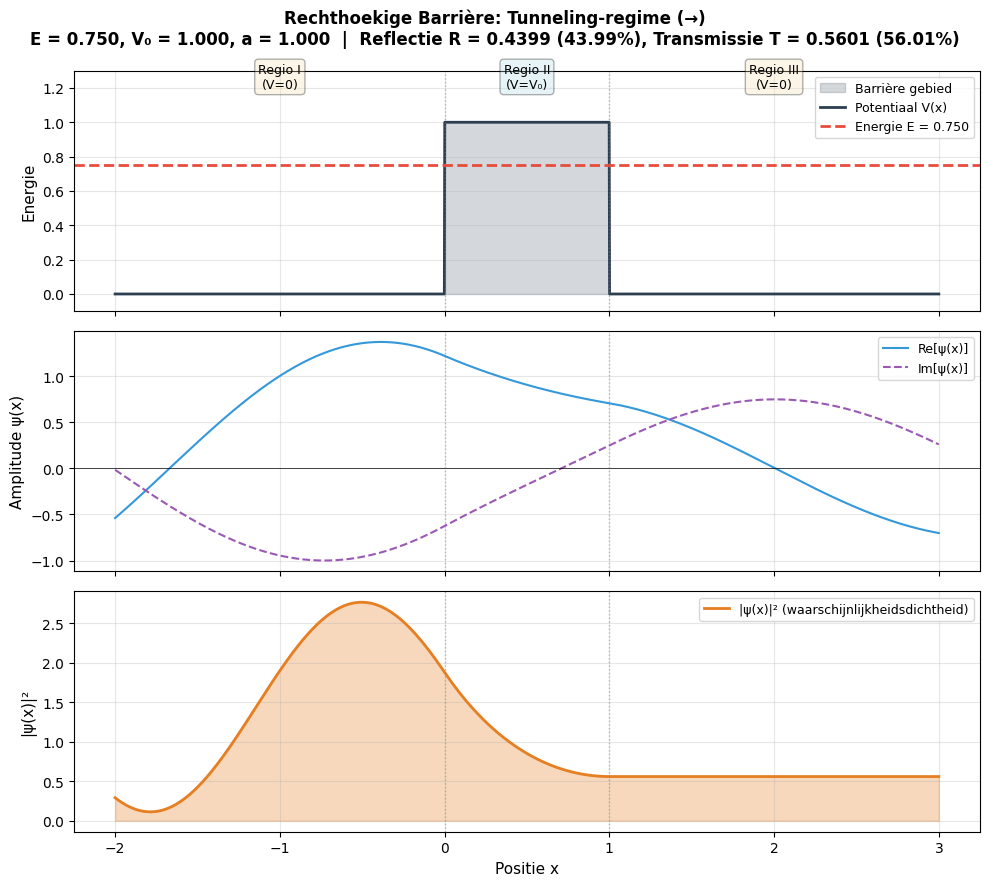

{'regime': 'tunnel',
 'k': np.float64(1.224744871391589),
 'kappa': np.float64(0.7071067811865476),
 'r': np.complex128(0.21995944857874578-0.625728965398299j),
 't': np.complex128(0.4729525115732015-0.5799974350280431j),
 'A': np.complex128(0.06808254437069204+0.3626704508136783j),
 'B': np.complex128(1.1518769042080537-0.9883994162119772j)}

In [6]:
V0 = 1.0
a  = 1.0
E  = 0.75 * V0

plot_schema(E, V0=V0, a=a, incident_from="left")

### Voorbeeld 2: Tunneling met E = 0.75 V₀ (invallend van rechts)

Dit toont aan dat tunneling symmetrisch is - het maakt niet uit van welke kant het deeltje komt!

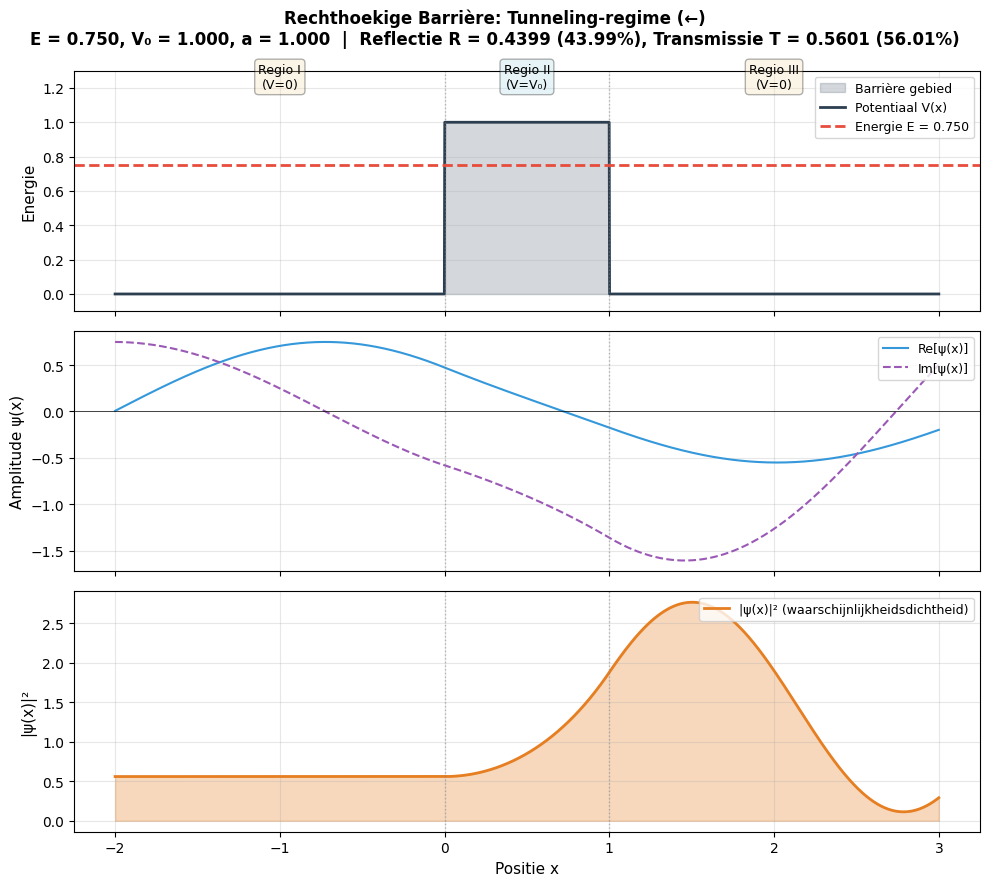

{'regime': 'tunnel',
 'k': np.float64(1.224744871391589),
 'kappa': np.float64(0.7071067811865476),
 'r': np.complex128(-0.568661756575879+0.3413835141970495j),
 't': np.complex128(0.47295251157320145-0.579997435028043j),
 'A': np.complex128(-0.2658162570774989-0.6995876073200676j),
 'B': np.complex128(0.7387687686507003+0.11959017229202457j)}

In [7]:
plot_schema(E, V0=V0, a=a, incident_from="right")